# Lunar Subsurface Ice Detection from Chandrayaan-2 DFSAR

### Compact-polarimetry CPR / DOP analysis with a physics-informed U-Net

**Objective:** detect subsurface water-ice in permanently and doubly shadowed
craters near the lunar south pole (Faustini region).

**Instrument:** Chandrayaan-2 DFSAR, L-band compact polarimetry (circular
transmit, dual H/V receive), Single-Look-Complex products.

---

#### Physical basis
A single specular reflection inverts circular polarization handedness, so smooth
regolith yields a Circular Polarization Ratio below unity (CPR < 1). Volumetric
and coherent-backscatter returns from fractured ice preserve handedness and raise
the ratio above unity (CPR > 1). Wavelength-scale surface roughness produces the
same effect, so CPR alone is ambiguous. The Degree of Polarization (DOP)
resolves it: multiple scattering within ice randomizes the phase and lowers DOP,
whereas rough surfaces remain comparatively polarized.

> Ice discriminator: **CPR > 1.0 and DOP < 0.13**

#### Modeling approach
In the absence of in-situ ground truth for lunar polar ice, the detector is
trained on physically realistic synthetic compact-polarimetry scenes and applied
to the real DFSAR products. The polarimetric feature extraction (CPR, DOP) is
identical for synthetic and observed data.

#### Workflow
1. Generate synthetic compact-polarimetry scenes (ice, rough-rock, smooth-regolith).
2. Train a physics-informed U-Net to produce a continuous ice-probability map.
3. Benchmark against the deterministic CPR/DOP threshold detector.
4. Apply the trained model to a real DFSAR scene and export a probability raster.


## 1. Setup

In [ ]:
import os, sys, glob, json, time
import numpy as np
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = os.path.abspath(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.synth import SceneConfig, make_compact_dataset, COMPACT_CHANNELS
from src.polarimetry import ice_threshold_mask
from src.train import (ChannelNormalizer, TrainConfig, train_model, predict,
                       pixel_metrics, baseline_metrics, best_threshold)
from src.dataio import dfsar_compact_features, predict_scene, save_geotiff

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch", torch.__version__, "| compute device:", DEVICE)

os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)


## 2. Configuration

In [ ]:
scene = SceneConfig(height=128, width=128, looks=6,
                    ice_fraction=0.18, rough_fraction=0.30)

N_TRAIN, N_VAL, N_TEST = 3000, 400, 400
tcfg = TrainConfig(epochs=200, batch_size=24, base_width=32, depth=4,
                   w_dice=1.0, w_phys=0.5, device=DEVICE)

CPR_IDX, DOP_IDX = 0, 1   # channel order: [CPR, DOP]
print("channels:", COMPACT_CHANNELS, "| scenes (train/val/test):", N_TRAIN, N_VAL, N_TEST)


## 3. Synthetic compact-polarimetry dataset

In [ ]:
t0 = time.time()
Xtr, Ytr = make_compact_dataset(N_TRAIN, scene, seed=1)
Xva, Yva = make_compact_dataset(N_VAL,   scene, seed=2)
Xte, Yte = make_compact_dataset(N_TEST,  scene, seed=3)
print("generated %d scenes in %.1fs" % (N_TRAIN+N_VAL+N_TEST, time.time()-t0))
print("training tensor", Xtr.shape, "| ice fraction = %.3f" % Ytr.mean())


### Representative scene

In [ ]:
sc, lab = Xtr[0], Ytr[0]
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
im0 = ax[0].imshow(sc[0], cmap="magma", vmax=np.percentile(sc[0], 99))
ax[0].set_title("CPR"); ax[0].axis("off"); plt.colorbar(im0, ax=ax[0], fraction=0.046)
im1 = ax[1].imshow(sc[1], cmap="viridis", vmin=0, vmax=1)
ax[1].set_title("DOP"); ax[1].axis("off"); plt.colorbar(im1, ax=ax[1], fraction=0.046)
ax[2].imshow(lab, cmap="gray"); ax[2].set_title("ice mask"); ax[2].axis("off")
plt.tight_layout(); plt.show()


### Class separability in CPR-DOP space
Ice occupies the high-CPR, low-DOP region; rough rock shares high CPR but higher
DOP; smooth regolith sits at low CPR. Dashed lines mark the deterministic
thresholds. Speckle blurs the boundary, motivating a spatial-context model.

In [ ]:
cpr = Xtr[:, 0].ravel(); dop = Xtr[:, 1].ravel(); yf = Ytr.ravel().astype(bool)
idx = np.random.default_rng(0).choice(len(cpr), size=min(20000, len(cpr)), replace=False)
plt.figure(figsize=(6, 5))
plt.scatter(cpr[idx][~yf[idx]], dop[idx][~yf[idx]], s=3, alpha=0.2, label="non-ice")
plt.scatter(cpr[idx][ yf[idx]], dop[idx][ yf[idx]], s=3, alpha=0.3, label="ice")
plt.axvline(1.0, ls="--", c="k"); plt.axhline(0.13, ls="--", c="k")
plt.xlim(0, 3); plt.ylim(0, 1)
plt.xlabel("CPR"); plt.ylabel("DOP"); plt.title("CPR-DOP feature space"); plt.legend(); plt.show()


## 4. Feature normalization and deterministic baseline

In [ ]:
norm = ChannelNormalizer(log_channels=(CPR_IDX,)).fit(Xtr)
Xtr_n, Xva_n, Xte_n = norm.transform(Xtr), norm.transform(Xva), norm.transform(Xte)

base = baseline_metrics(Xte, Yte, cpr_idx=CPR_IDX, dop_idx=DOP_IDX)
print("Deterministic detector (CPR > 1.0 and DOP < 0.13), test set:")
for k in ["iou", "f1", "precision", "recall", "accuracy"]:
    print("  %-10s %.3f" % (k, base[k]))


## 5. Physics-informed U-Net training

In [7]:
model, history, best_val_iou, best_thr = train_model(
    Xtr_n, Ytr, Xva_n, Yva, tcfg, cpr_idx=CPR_IDX, dop_idx=DOP_IDX, verbose=True)
print("\nbest validation IoU = %.3f at decision threshold %.2f" % (best_val_iou, best_thr))


epoch   2/50 | loss 0.7747 | val IoU 0.979 | F1 0.990 | AUC 1.000 | thr 0.52
epoch   3/50 | loss 0.6186 | val IoU 0.986 | F1 0.993 | AUC 1.000 | thr 0.52
epoch   4/50 | loss 0.4975 | val IoU 0.990 | F1 0.995 | AUC 1.000 | thr 0.46
epoch   5/50 | loss 0.4014 | val IoU 0.991 | F1 0.995 | AUC 1.000 | thr 0.52
epoch   6/50 | loss 0.3253 | val IoU 0.993 | F1 0.996 | AUC 1.000 | thr 0.54
epoch   7/50 | loss 0.2661 | val IoU 0.994 | F1 0.997 | AUC 1.000 | thr 0.54
epoch   8/50 | loss 0.2208 | val IoU 0.995 | F1 0.998 | AUC 1.000 | thr 0.56
epoch   9/50 | loss 0.1868 | val IoU 0.996 | F1 0.998 | AUC 1.000 | thr 0.54
epoch  10/50 | loss 0.1611 | val IoU 0.996 | F1 0.998 | AUC 1.000 | thr 0.67
epoch  11/50 | loss 0.1414 | val IoU 0.996 | F1 0.998 | AUC 1.000 | thr 0.63
epoch  12/50 | loss 0.1260 | val IoU 0.997 | F1 0.998 | AUC 1.000 | thr 0.48
epoch  13/50 | loss 0.1132 | val IoU 0.996 | F1 0.998 | AUC 1.000 | thr 0.58
epoch  14/50 | loss 0.1038 | val IoU 0.997 | F1 0.998 | AUC 1.000 | thr 0.58

### Training history

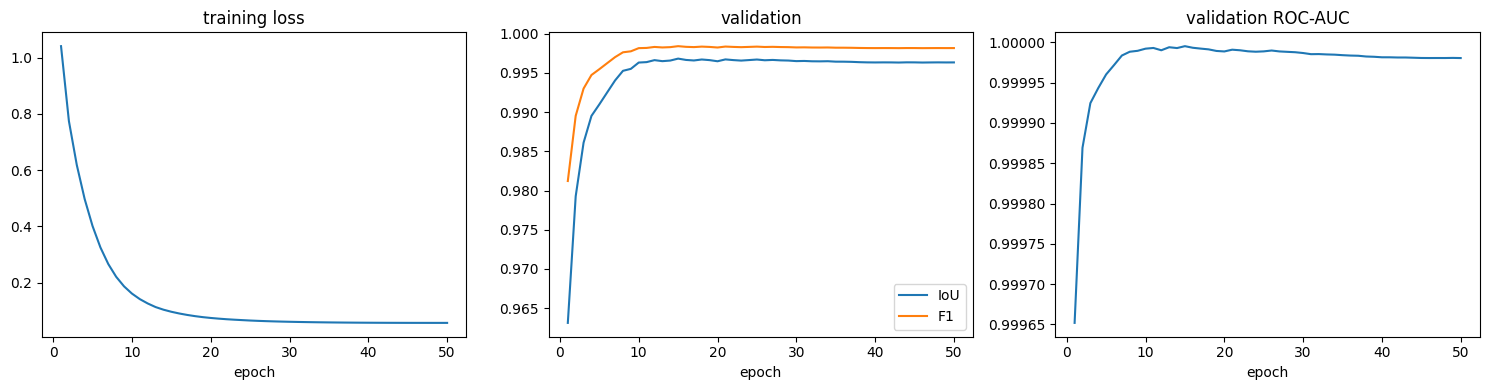

In [8]:
ep = range(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(ep, history["train_loss"]); ax[0].set_title("training loss"); ax[0].set_xlabel("epoch")
ax[1].plot(ep, history["val_iou"], label="IoU"); ax[1].plot(ep, history["val_f1"], label="F1")
ax[1].set_title("validation"); ax[1].set_xlabel("epoch"); ax[1].legend()
ax[2].plot(ep, history["val_auc"]); ax[2].set_title("validation ROC-AUC"); ax[2].set_xlabel("epoch")
plt.tight_layout(); plt.show()


## 6. Evaluation: U-Net versus deterministic detector

In [9]:
prob_te = predict(model, Xte_n, DEVICE, tcfg.batch_size)
cnn = pixel_metrics(prob_te, Yte, thr=best_thr)
print("%-12s %12s %12s" % ("metric", "baseline", "U-Net"))
for k in ["iou", "f1", "precision", "recall", "accuracy"]:
    print("%-12s %12.3f %12.3f" % (k, base[k], cnn[k]))
print("U-Net ROC-AUC %.3f | PR-AUC %.3f" % (cnn.get("roc_auc", float('nan')),
                                            cnn.get("pr_auc", float('nan'))))


metric           baseline        U-Net
iou                 0.505        0.997
f1                  0.671        0.998
precision           0.991        0.999
recall              0.508        0.998
accuracy            0.911        0.999
U-Net ROC-AUC 1.000 | PR-AUC 1.000


### Prediction example

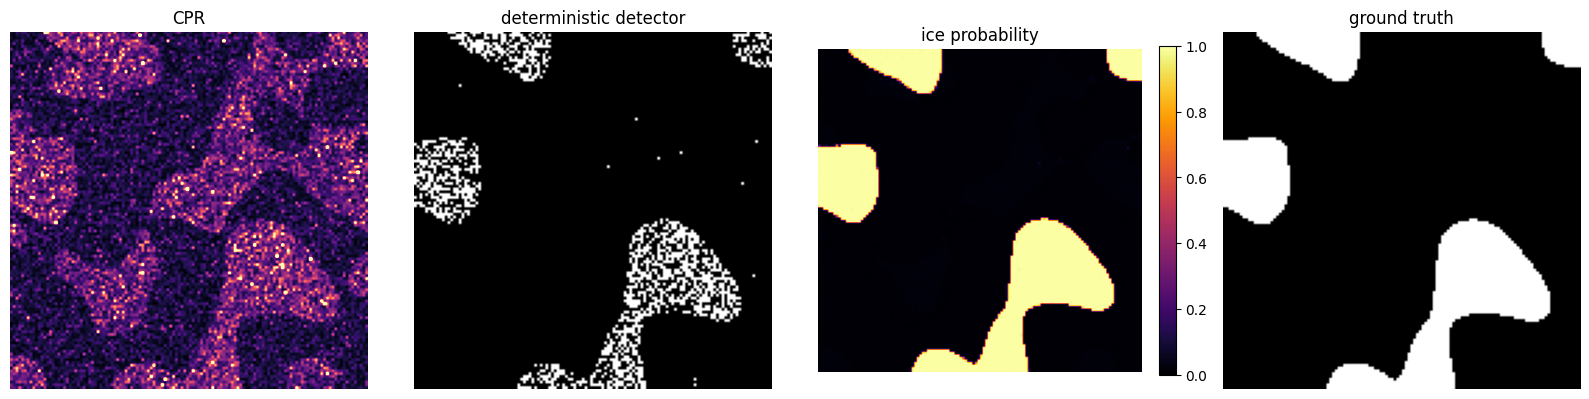

In [10]:
k = 0
Xs, ys = Xte[k], Yte[k]
prob = predict(model, norm.transform(Xs[None]), DEVICE)[0]
base_pred = ice_threshold_mask(Xs[0], Xs[1]).astype(float)
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(Xs[0], cmap="magma", vmax=np.percentile(Xs[0], 99)); ax[0].set_title("CPR"); ax[0].axis("off")
ax[1].imshow(base_pred, cmap="gray"); ax[1].set_title("deterministic detector"); ax[1].axis("off")
im = ax[2].imshow(prob, cmap="inferno", vmin=0, vmax=1); ax[2].set_title("ice probability"); ax[2].axis("off")
plt.colorbar(im, ax=ax[2], fraction=0.046)
ax[3].imshow(ys, cmap="gray"); ax[3].set_title("ground truth"); ax[3].axis("off")
plt.tight_layout(); plt.show()


## 7. Model export

In [11]:
ckpt = {"state_dict": model.state_dict(), "in_ch": 2,
        "base_width": tcfg.base_width, "depth": tcfg.depth,
        "channels": COMPACT_CHANNELS, "best_threshold": float(best_thr),
        "normalizer": norm.state()}
torch.save(ckpt, "models/ice_unet.pt")
with open("models/metrics.json", "w") as f:
    json.dump({"baseline": base, "cnn": cnn, "best_threshold": float(best_thr)}, f, indent=2)
print("saved models/ice_unet.pt and models/metrics.json")


saved models/ice_unet.pt and models/metrics.json


## 8. Application to a Chandrayaan-2 DFSAR scene

The compact-polarimetry Single-Look-Complex channels (`sli` lh/lv) are read
directly from the product archive, multilooked, and converted to CPR and DOP.
Both the deterministic detector and the trained model are then applied, and the
probability map is exported as a GeoTIFF.

In [12]:
zips = sorted(glob.glob("data/raw/dfsar/*.zip"))
print("available DFSAR products:", len(zips))
for z in zips[:12]:
    print("  ", os.path.basename(z), "%.2f GB" % (os.path.getsize(z)/1e9))
assert zips, "No DFSAR products found in data/raw/dfsar/."


available DFSAR products: 12
   ch2_sar_ncxl_20251026t125618324_d_cp_d18.zip 4.65 GB
   ch2_sar_ncxl_20251026t224558634_d_cp_d18.zip 0.46 GB
   ch2_sar_ncxl_20251027t083542014_d_cp_d32.zip 2.53 GB
   ch2_sar_ncxl_20251027t123135679_d_cp_d32.zip 3.05 GB
   ch2_sar_ncxl_20251027t222118140_d_cp_d18.zip 2.12 GB
   ch2_sar_ncxl_20251028t100854528_d_cp_d18.zip 2.56 GB
   ch2_sar_ncxl_20251028t140444956_d_cp_d18.zip 3.32 GB
   ch2_sar_ncxl_20251028t235421453_d_cp_d18.zip 2.93 GB
   ch2_sar_ncxl_20251029t094419398_d_cp_d18.zip 2.48 GB
   ch2_sar_ncxl_20251029t133947000_d_cp_d18.zip 3.49 GB
   ch2_sar_ncxl_20251029t153741564_d_cp_d18.zip 3.63 GB
   ch2_sar_ncxl_20251029t232923718_d_cp_d18.zip 3.62 GB


In [13]:
SCENE_ZIP = zips[0]
AZ_START, AZ_LEN, LOOKS = 100000, 24000, 9

t0 = time.time()
real = dfsar_compact_features(SCENE_ZIP, az_start=AZ_START, az_len=AZ_LEN, looks=LOOKS)
cpr_r, dop_r, feat = real["cpr"], real["dop"], real["feat"]
print("processed %s in %.1fs | multilooked map %s" %
      (os.path.basename(SCENE_ZIP), time.time()-t0, cpr_r.shape))
print("CPR median %.3f | DOP median %.3f | CPR>1 %.2f%% | DOP<0.13 %.2f%%" %
      (np.median(cpr_r), np.median(dop_r), 100*np.mean(cpr_r>1), 100*np.mean(dop_r<0.13)))


processed ch2_sar_ncxl_20251026t125618324_d_cp_d18.zip in 42.7s | multilooked map (2667, 128)
CPR median 0.160 | DOP median 0.703 | CPR>1 2.63% | DOP<0.13 10.33%


In [14]:
base_mask = ice_threshold_mask(cpr_r, dop_r).astype(np.float32)
prob_map = predict_scene(model, norm, feat, DEVICE, tile=128, overlap=24)

save_geotiff("outputs/real_ice_probability.tif", prob_map)
print("exported outputs/real_ice_probability.tif", prob_map.shape)
print("deterministic ice pixels %.3f%% | model ice pixels %.3f%%" %
      (100*base_mask.mean(), 100*np.mean(prob_map >= best_thr)))


exported outputs/real_ice_probability.tif (2667, 128)
deterministic ice pixels 0.482% | model ice pixels 10.372%


C:\workspace\yes-scan-apex\yes_scan_prototype\.venv\lib\site-packages\rasterio\__init__.py:397: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


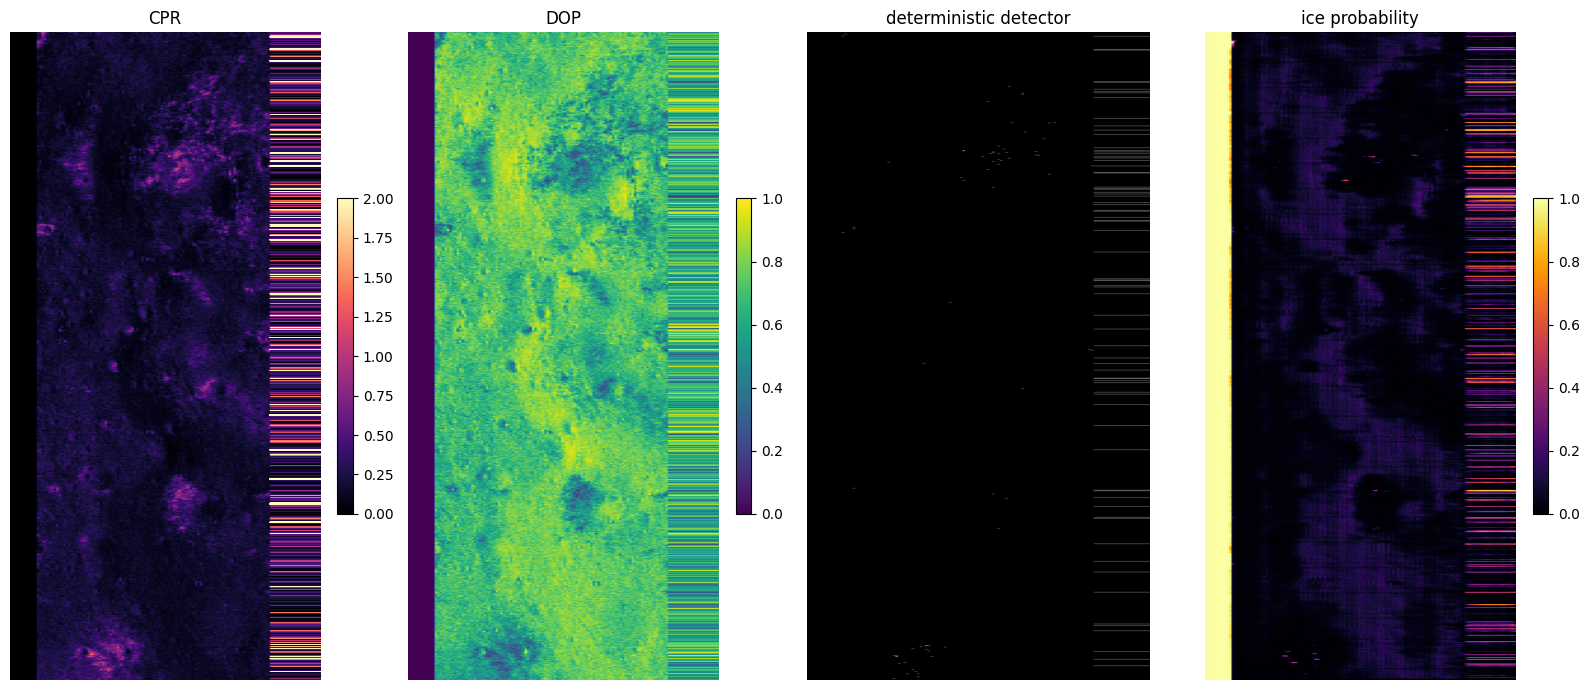

In [15]:
def squash(a, maxw=1400):
    return a[::max(1, a.shape[0]//maxw)]
fig, ax = plt.subplots(1, 4, figsize=(16, 7))
im0 = ax[0].imshow(squash(cpr_r), cmap="magma", vmin=0, vmax=2, aspect="auto"); ax[0].set_title("CPR"); ax[0].axis("off"); plt.colorbar(im0, ax=ax[0], fraction=0.046)
im1 = ax[1].imshow(squash(dop_r), cmap="viridis", vmin=0, vmax=1, aspect="auto"); ax[1].set_title("DOP"); ax[1].axis("off"); plt.colorbar(im1, ax=ax[1], fraction=0.046)
ax[2].imshow(squash(base_mask), cmap="gray", aspect="auto"); ax[2].set_title("deterministic detector"); ax[2].axis("off")
im3 = ax[3].imshow(squash(prob_map), cmap="inferno", vmin=0, vmax=1, aspect="auto"); ax[3].set_title("ice probability"); ax[3].axis("off"); plt.colorbar(im3, ax=ax[3], fraction=0.046)
plt.tight_layout(); plt.show()
